# LAB 01A — Coordinate Systems for Mineral Exploration

## Executive summary

Spatial proximity is a common source of predictive information in mineral exploration.

Features such as distance to geological faults, lithological contacts, intrusions, geochemical anomalies, or known mineral occurrences may later become inputs to a machine-learning model.

However, spatial distance is only meaningful when the coordinate reference system (CRS) and its units are correctly understood.

This laboratory demonstrates a simple but important failure mode:

> Code can run correctly while the resulting spatial feature is scientifically wrong.

Using two synthetic locations in northern Chile, we compare:

1. distance calculated directly from geographic coordinates;
2. distance after projection to UTM;
3. geodesic distance over the WGS84 ellipsoid.

The objective is not merely to calculate a distance, but to establish a reproducible workflow for spatial feature engineering.

## 1. Problem

Suppose an exploration workflow needs to estimate the distance between two spatial observations.

Later, the same operation could represent:

- distance to a geological fault;
- distance to an intrusive body;
- distance to a lithological contact;
- distance to a known mineral occurrence;
- distance to a geochemical anomaly.

A common mistake is to calculate distance directly from longitude and latitude and interpret the result as metres.

Longitude and latitude in EPSG:4326 are angular coordinates expressed in degrees.

Therefore:

**distance calculated directly in EPSG:4326 is not a metric distance.**

In [15]:
from __future__ import annotations

import geopandas as gpd
import matplotlib.pyplot as plt

from pyproj import Geod
from shapely.geometry import Point

from geoai.crs import (
    utm_zone_from_longitude,
    wgs84_utm_epsg,
)

## 2. Scenario

Two synthetic locations are created in northern Chile.

Synthetic coordinates are used intentionally so the laboratory remains reproducible and independent of private or licensed exploration data.

In [16]:
from IPython.display import display

locations = gpd.GeoDataFrame(
    {
        "site": ["SITE_A", "SITE_B"],
    },
    geometry=[
        Point(-70.4000, -23.6000),
        Point(-70.3900, -23.5900),
    ],
    crs="EPSG:4326",
)

display(locations)

print()
print("Coordinate Reference System (CRS)")
print("---------------------------------")
print(f"EPSG code : {locations.crs.to_epsg()}")
print(f"CRS name  : {locations.crs.name}")
print(f"CRS       : {locations.crs}")

,site,geometry
0,SITE_A,POINT (-70.4 -23.6)
1,SITE_B,POINT (-70.39 -23.59)



Coordinate Reference System (CRS)
---------------------------------
EPSG code : 4326
CRS name  : WGS 84
CRS       : EPSG:4326


### What does EPSG:4326 mean?

The two locations are stored in **WGS 84 / EPSG:4326**, the geographic coordinate system commonly used by GPS and many spatial datasets.

The coordinates represent:

- **X → longitude**
- **Y → latitude**

and their units are **degrees**, not metres.

This distinction becomes critical when calculating distances, areas, buffers, or proximity-based features.

## 3. Experiment 1 — The misleading calculation

Shapely can calculate the numerical separation between the two coordinate pairs.

The calculation itself is valid.

The interpretation is not.

Because the coordinates are expressed in longitude and latitude, the resulting value is expressed in degrees rather than metres.

In [17]:
degree_distance = locations.geometry.iloc[0].distance(
    locations.geometry.iloc[1]
)

print(f"Raw distance: {degree_distance:.8f}")
print("Coordinate unit: degrees")

Raw distance: 0.01414214
Coordinate unit: degrees


### Finding

The value `0.01414214` is numerically correct for the coordinate values supplied to the algorithm.

It does **not** mean:

- 0.014 metres;
- 0.014 kilometres;
- or any other direct physical distance.

This illustrates an important GeoAI principle:

> computational correctness does not guarantee geospatial validity.

## 4. Selecting an appropriate projected CRS

For local metric analysis, the observations can be projected to an appropriate UTM zone.

Rather than manually hard-coding the EPSG identifier, we derive the UTM zone from the location.

In [18]:
reference_lon = locations.geometry.x.mean()
reference_lat = locations.geometry.y.mean()

utm_zone = utm_zone_from_longitude(reference_lon)
utm_epsg = wgs84_utm_epsg(
    reference_lon,
    reference_lat,
)

print("Reference longitude:", round(reference_lon, 4))
print("Reference latitude :", round(reference_lat, 4))
print("UTM zone           :", utm_zone)
print("EPSG               :", utm_epsg)

Reference longitude: -70.395
Reference latitude : -23.595
UTM zone           : 19
EPSG               : 32719


### Independent CRS check

The custom utility makes the UTM selection rule explicit and testable.

For real GeoDataFrames, GeoPandas also provides `estimate_utm_crs()`.

Comparing both approaches provides an additional consistency check rather than relying on a single implementation.

In [19]:
estimated_crs = locations.estimate_utm_crs()

print("Custom EPSG     :", utm_epsg)
print("GeoPandas CRS   :", estimated_crs)
print("GeoPandas EPSG  :", estimated_crs.to_epsg())

assert estimated_crs.to_epsg() == utm_epsg

Custom EPSG     : 32719
GeoPandas CRS   : EPSG:32719
GeoPandas EPSG  : 32719


## 5. Projected distance in UTM

After transforming the observations from geographic coordinates to **WGS 84 / UTM Zone 19S (EPSG:32719)**, the coordinates are expressed in **metres**.

This allows us to calculate a physically interpretable planar distance between the two locations.

The same operation that previously returned a value in degrees can now be interpreted directly in metric units.

In [20]:
locations_utm = locations.to_crs(epsg=utm_epsg)

utm_distance_m = locations_utm.geometry.iloc[0].distance(
    locations_utm.geometry.iloc[1]
)

print(f"Projected distance: {utm_distance_m:.2f} m")
print(f"Projected distance: {utm_distance_m / 1000:.4f} km")

Projected distance: 1505.89 m
Projected distance: 1.5059 km


## 6. Independent distance validation

UTM represents the Earth's curved surface on a projected plane.

For an independent reference, we also calculate geodesic distance using the WGS84 ellipsoid.

For two nearby locations inside an appropriate UTM zone, the two results should be very similar.

In [21]:
geod = Geod(ellps="WGS84")

lon1 = locations.geometry.iloc[0].x
lat1 = locations.geometry.iloc[0].y
lon2 = locations.geometry.iloc[1].x
lat2 = locations.geometry.iloc[1].y

azimuth, _, geodesic_distance_m = geod.inv(
    lon1,
    lat1,
    lon2,
    lat2,
)

absolute_difference_m = abs(
    utm_distance_m - geodesic_distance_m
)

relative_difference_pct = (
    absolute_difference_m / geodesic_distance_m
) * 100

print(f"UTM distance       : {utm_distance_m:.2f} m")
print(f"Geodesic distance  : {geodesic_distance_m:.2f} m")
print(f"Difference         : {absolute_difference_m:.4f} m")
print(f"Relative difference: {relative_difference_pct:.6f} %")
print(f"Forward azimuth    : {azimuth:.2f}°")

UTM distance       : 1505.89 m
Geodesic distance  : 1506.12 m
Difference         : 0.2255 m
Relative difference: 0.014974 %
Forward azimuth    : 42.67°


## 7. Visual evidence

The following plot shows the two observations in the projected coordinate system.

Because the axes are now expressed in metres, the geometry has a physically interpretable spatial scale.

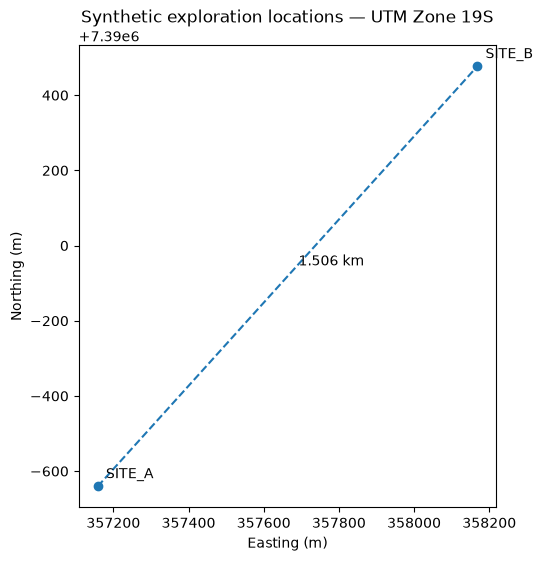

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

locations_utm.plot(
    ax=ax,
    marker="o",
)

for _, row in locations_utm.iterrows():
    ax.annotate(
        row["site"],
        (row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
    )

x_values = locations_utm.geometry.x.to_list()
y_values = locations_utm.geometry.y.to_list()

ax.plot(x_values, y_values, linestyle="--")

mid_x = sum(x_values) / 2
mid_y = sum(y_values) / 2

ax.annotate(
    f"{utm_distance_m / 1000:.3f} km",
    (mid_x, mid_y),
    xytext=(8, 8),
    textcoords="offset points",
)

ax.set_title("Synthetic exploration locations — UTM Zone 19S")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")

plt.show()

## 8. Interpretation

The same pair of locations generated two very different types of numerical output:

| Method | Result | Interpretation |
|---|---:|---|
| EPSG:4326 planar calculation | ~0.014142 | angular separation in degrees |
| UTM 19S | ~1505.89 m | local projected distance |
| WGS84 geodesic | ~1506.12 m | ellipsoidal reference distance |

The UTM and geodesic estimates differ by only a small fraction of one percent in this local example.

The important result is therefore not simply that the distance is approximately 1.5 km.

The important result is that **distance-based features must carry an explicit spatial reference and unit definition before they are used in analytical or machine-learning workflows.**

## 9. Application to mineral exploration

The same principle applies when engineering predictors such as:

`distance_to_fault_m`

`distance_to_intrusive_m`

`distance_to_contact_m`

`distance_to_occurrence_m`

`distance_to_geochemical_anomaly_m`

These variables may later be used by machine-learning or mineral prospectivity models.

If their CRS or units are incorrect, the model may still train successfully while learning from scientifically invalid features.

This is a particularly dangerous failure mode because it may not generate a software error.

## 10. Engineering controls

This laboratory is supported by reusable and tested project code.

CRS utilities are implemented in:

`src/geoai/crs.py`

Automated validation is implemented in:

`tests/test_crs.py`

The tests cover:

- WGS84 UTM zone derivation;
- northern and southern hemispheres;
- invalid longitudes;
- UTM latitude limits;
- longitude boundary cases;
- the UTM 18/19 boundary relevant to Chile.

This separates exploratory communication from reusable production-oriented logic.

## 11. Limitations

UTM is highly useful for local and regional metric analysis, but it is not automatically the best CRS for every spatial problem.

Additional considerations include:

- study-area extent;
- crossing UTM zones;
- raster CRS;
- source geological data;
- distortion objectives;
- regional versus local analyses.

The next laboratory examines what happens when an analysis crosses a UTM zone boundary.

## Key takeaway

> A spatial pipeline can be reproducible, executable, and mathematically consistent while still being geoscientifically incorrect.

Correct GeoAI requires explicit control of:

**CRS → units → spatial operation → validation → interpretation.**